In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

df_co2 = pd.read_csv(
    url,
    comment="#",        
    sep="\s+",          
    header=None,        
    names=["year", "month", "decimal_date", "co2_avg", "co2_deseason", "ndays", "std", "unc"]
)

print(df_co2.shape)
print(df_co2.head(10))

(816, 8)
   year  month  decimal_date  co2_avg  co2_deseason  ndays   std   unc
0  1958      3     1958.2027   315.71        314.44     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45        315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51        314.69     -1 -9.99 -0.99
3  1958      6     1958.4548   317.27        315.15     -1 -9.99 -0.99
4  1958      7     1958.5370   315.87        315.20     -1 -9.99 -0.99
5  1958      8     1958.6219   314.93        316.21     -1 -9.99 -0.99
6  1958      9     1958.7068   313.21        316.11     -1 -9.99 -0.99
7  1958     10     1958.7890   312.42        315.41     -1 -9.99 -0.99
8  1958     11     1958.8740   313.33        315.21     -1 -9.99 -0.99
9  1958     12     1958.9562   314.67        315.43     -1 -9.99 -0.99


In [3]:
!pip install netCDF4 xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 5.1 MB/s  0:00:045.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [netCDF4]


In [4]:
import xarray as xr
print("xarray hazır!")

xarray hazır!


In [6]:
import glob
nc_files = glob.glob("data/*.nc")
print("Bulunan dosyalar:")
for f in nc_files:
    print(f)

Bulunan dosyalar:


In [8]:
import os

print(os.getcwd()) 

/Users/melis


In [9]:
import os

os.chdir("/Users/melis/Desktop/climate-analysis")
print(os.getcwd())

/Users/melis/Desktop/climate-analysis


In [11]:
print(os.listdir("."))

['.DS_Store', 'data:']


In [13]:
print(os.listdir("data:"))

['SBBX.HadR2', 'SBBX1880.Ts.GHCNv4.1200', 'GlobalLandTemperaturesByCountry.csv', 'mlo_station_data_set.zip', '.DS_Store', 'SBBX1880.Ts.GHCNv4.250', 'gistemp250_GHCNv4.zarr.tar', 'GlobalLandTemperaturesByMajorCity.csv', 'gistemp250_GHCNv4.nc', 'gistemp1200_GHCNv4_ERSSTv5.nc', 'GlobalLandTemperaturesByState.csv', 'GlobalTemperatures.csv', 'gistemp1200_GHCNv4_ERSSTv5.zarr.tar', 'GlobalLandTemperaturesByCity.csv']


In [14]:
df_global = pd.read_csv("data:/GlobalTemperatures.csv")

print(df_global.shape)
print(df_global.head())

(3192, 9)
           dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
0  1750-01-01                   3.034                              3.574   
1  1750-02-01                   3.083                              3.702   
2  1750-03-01                   5.626                              3.076   
3  1750-04-01                   8.490                              2.451   
4  1750-05-01                  11.573                              2.072   

   LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
0                 NaN                            NaN                 NaN   
1                 NaN                            NaN                 NaN   
2                 NaN                            NaN                 NaN   
3                 NaN                            NaN                 NaN   
4                 NaN                            NaN                 NaN   

   LandMinTemperatureUncertainty  LandAndOceanAverageTemperature  \
0       

In [15]:
print(df_global.columns.tolist())
print(df_global.dtypes)
print(df_global.isnull().sum())

['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty']
dt                                            object
LandAverageTemperature                       float64
LandAverageTemperatureUncertainty            float64
LandMaxTemperature                           float64
LandMaxTemperatureUncertainty                float64
LandMinTemperature                           float64
LandMinTemperatureUncertainty                float64
LandAndOceanAverageTemperature               float64
LandAndOceanAverageTemperatureUncertainty    float64
dtype: object
dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200


In [18]:
df_global["dt"] = pd.to_datetime(df_global["dt"])
df_global["year"] = df_global["dt"].dt.year
df_global = df_global.dropna(subset=["LandAverageTemperature"])

print("Temizlendi! ✓")
print(df_global.shape)
print(df_global.head())
                            

Temizlendi! ✓
(3180, 10)
          dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
0 1750-01-01                   3.034                              3.574   
1 1750-02-01                   3.083                              3.702   
2 1750-03-01                   5.626                              3.076   
3 1750-04-01                   8.490                              2.451   
4 1750-05-01                  11.573                              2.072   

   LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
0                 NaN                            NaN                 NaN   
1                 NaN                            NaN                 NaN   
2                 NaN                            NaN                 NaN   
3                 NaN                            NaN                 NaN   
4                 NaN                            NaN                 NaN   

   LandMinTemperatureUncertainty  LandAndOceanAverageTemperature  \

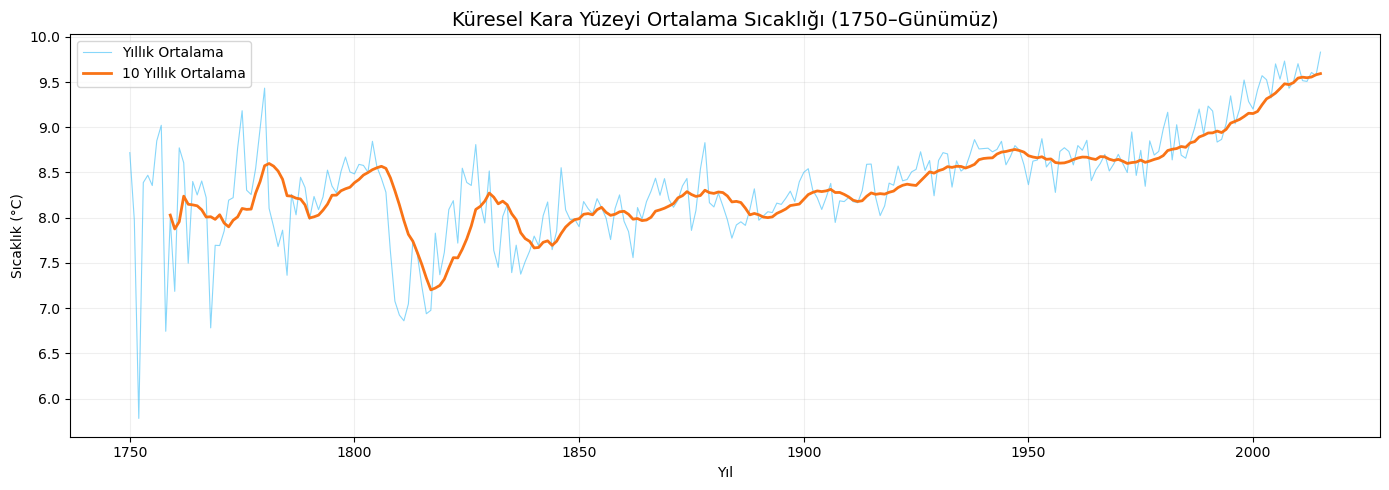

In [19]:

df_yearly = df_global.groupby("year")["LandAverageTemperature"].mean().reset_index()
plt.figure(figsize=(14, 5))
plt.plot(df_yearly["year"], df_yearly["LandAverageTemperature"], 
         color="#38bdf8", linewidth=0.8, alpha=0.6, label="Yıllık Ortalama")
df_yearly["rolling"] = df_yearly["LandAverageTemperature"].rolling(10).mean()
plt.plot(df_yearly["year"], df_yearly["rolling"], 
         color="#f97316", linewidth=2, label="10 Yıllık Ortalama")

plt.title("Küresel Kara Yüzeyi Ortalama Sıcaklığı (1750–Günümüz)", fontsize=14)
plt.xlabel("Yıl")
plt.ylabel("Sıcaklık (°C)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Gözlem 1: Küresel Isınma Trendi

1750'den günümüze küresel kara yüzeyi sıcaklığı incelendiğinde,
özellikle **1900lerin başından itibaren** belirgin bir artış trendi gözlemlenmektedir.
10 yıllık hareketli ortalama bu trendi daha net ortaya koymaktadır.

In [22]:
df_country = pd.read_csv("data:/GlobalLandTemperaturesBycountry.csv")
print(df_country.shape)
print(df_country.head())

(577462, 4)
           dt  AverageTemperature  AverageTemperatureUncertainty Country
0  1743-11-01               4.384                          2.294   Åland
1  1743-12-01                 NaN                            NaN   Åland
2  1744-01-01                 NaN                            NaN   Åland
3  1744-02-01                 NaN                            NaN   Åland
4  1744-03-01                 NaN                            NaN   Åland


In [23]:
df_country["dt"] = pd.to_datetime(df_country["dt"])
df_country["year"] = df_country["dt"].dt.year
df_country = df_country.dropna(subset=["AverageTemperature"])
df_turkey = df_country[df_country["Country"] == "Turkey"]
print(df_turkey.shape)
print(df_turkey.head())

(2838, 5)
               dt  AverageTemperature  AverageTemperatureUncertainty Country  \
533683 1777-02-01               3.000                          3.314  Turkey   
533685 1777-04-01               7.678                          2.553  Turkey   
533686 1777-05-01              15.293                          3.189  Turkey   
533687 1777-06-01              18.661                          2.993  Turkey   
533688 1777-07-01              20.757                          2.643  Turkey   

        year  
533683  1777  
533685  1777  
533686  1777  
533687  1777  
533688  1777  


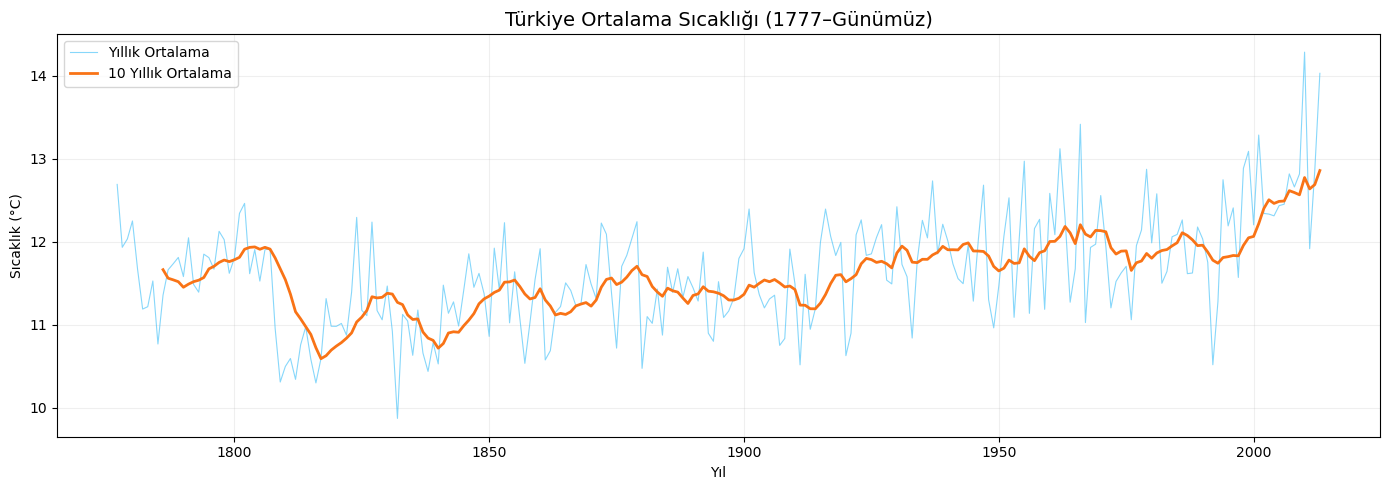

In [24]:
df_turkey_yearly = df_turkey.groupby("year")["AverageTemperature"].mean().reset_index()
plt.figure(figsize=(14, 5))
plt.plot(df_turkey_yearly["year"], df_turkey_yearly["AverageTemperature"],
         color="#38bdf8", linewidth=0.8, alpha=0.6, label="Yıllık Ortalama")
df_turkey_yearly["rolling"] = df_turkey_yearly["AverageTemperature"].rolling(10).mean()
plt.plot(df_turkey_yearly["year"], df_turkey_yearly["rolling"],
         color="#f97316", linewidth=2, label="10 Yıllık Ortalama")
plt.title("Türkiye Ortalama Sıcaklığı (1777–Günümüz)", fontsize=14)
plt.xlabel("Yıl")
plt.ylabel("Sıcaklık (°C)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Gözlem 2: Türkiye'de İklim Değişikliği

Türkiye'nin 1777'den günümüze sıcaklık verisi incelendiğinde,
**2000'li yıllardan itibaren** belirgin bir sıcaklık artışı gözlemlenmektedir.
Bu trend, küresel ısınma ile paralel bir seyir izlemektedir.

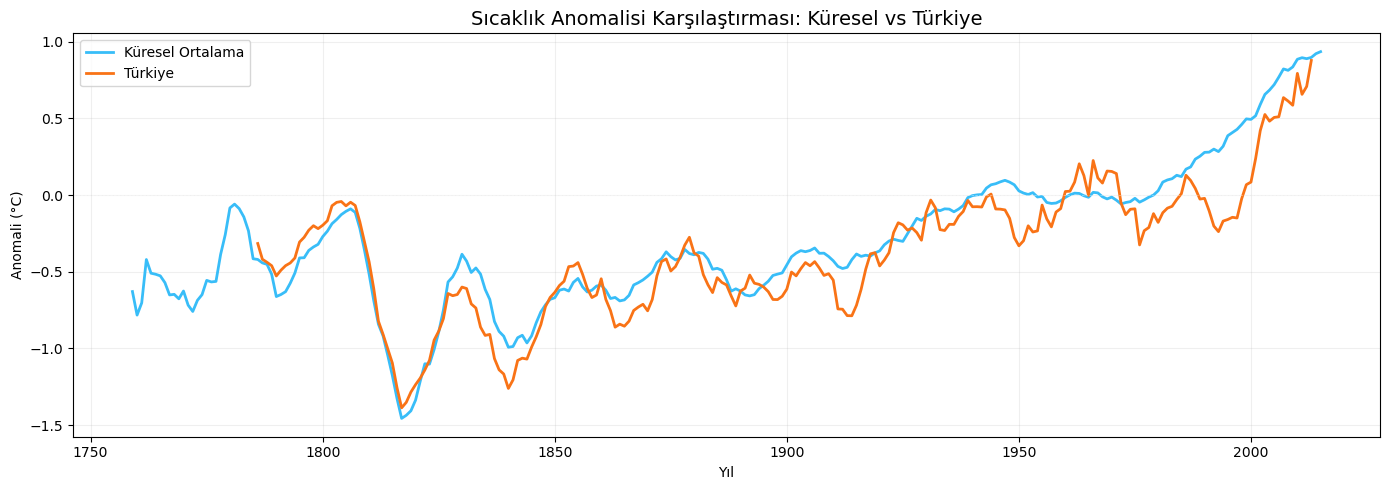

In [25]:
base_global = df_yearly[df_yearly["year"].between(1951, 1980)]["LandAverageTemperature"].mean()
base_turkey = df_turkey_yearly[df_turkey_yearly["year"].between(1951, 1980)]["AverageTemperature"].mean()
df_yearly["anomaly"] = df_yearly["LandAverageTemperature"] - base_global
df_turkey_yearly["anomaly"] = df_turkey_yearly["AverageTemperature"] - base_turkey

plt.figure(figsize=(14, 5))
plt.plot(df_yearly["year"], df_yearly["anomaly"].rolling(10).mean(),
         color="#38bdf8", linewidth=2, label="Küresel Ortalama")
plt.plot(df_turkey_yearly["year"], df_turkey_yearly["anomaly"].rolling(10).mean(),
         color="#f97316", linewidth=2, label="Türkiye")
plt.axhline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.5)
plt.title("Sıcaklık Anomalisi Karşılaştırması: Küresel vs Türkiye", fontsize=14)
plt.xlabel("Yıl")
plt.ylabel("Anomali (°C)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Gözlem 3: Küresel vs Türkiye Karşılaştırması

1951-1980 baz dönemi referans alındığında, hem küresel hem de Türkiye sıcaklık
anomalileri **1900'lerden itibaren** belirgin bir artış göstermektedir.
İki trend birbirine paralel seyretmekte olup Türkiye, küresel ısınmadan
doğrudan etkilenen bir ülke konumundadır.

In [27]:
gitignore = """
data:/*.nc
data:/*.zarr.tar
data:/*.zip
data:/SBBX*

# Jupyter checkpoints
.ipynb_checkpoints/

# Python
__pycache__/
*.pyc
.DS_Store
"""

with open(".gitignore", "w") as f:
    f.write(gitignore)

print(".gitignore oluşturuldu! ✓")

.gitignore oluşturuldu! ✓


In [28]:
# CO₂ verisini kontrol edelim
print(df_co2.head())
print(df_co2.shape)

   year  month  decimal_date  co2_avg  co2_deseason  ndays   std   unc
0  1958      3     1958.2027   315.71        314.44     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45        315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51        314.69     -1 -9.99 -0.99
3  1958      6     1958.4548   317.27        315.15     -1 -9.99 -0.99
4  1958      7     1958.5370   315.87        315.20     -1 -9.99 -0.99
(816, 8)


In [29]:

df_co2_yearly = df_co2.groupby("year")["co2_avg"].mean().reset_index()


df_temp_filtered = df_yearly[df_yearly["year"] >= 1958].copy()


df_merged = pd.merge(df_temp_filtered, df_co2_yearly, on="year")

print(df_merged.shape)
print(df_merged.head())

(58, 5)
   year  LandAverageTemperature   rolling   anomaly     co2_avg
0  1958                8.773750  8.606242  0.115794  315.237000
1  1959                8.732667  8.620833  0.074711  315.981667
2  1960                8.583750  8.642683 -0.074206  316.908333
3  1961                8.797667  8.659883  0.139711  317.643333
4  1962                8.745917  8.670650  0.087961  318.453333


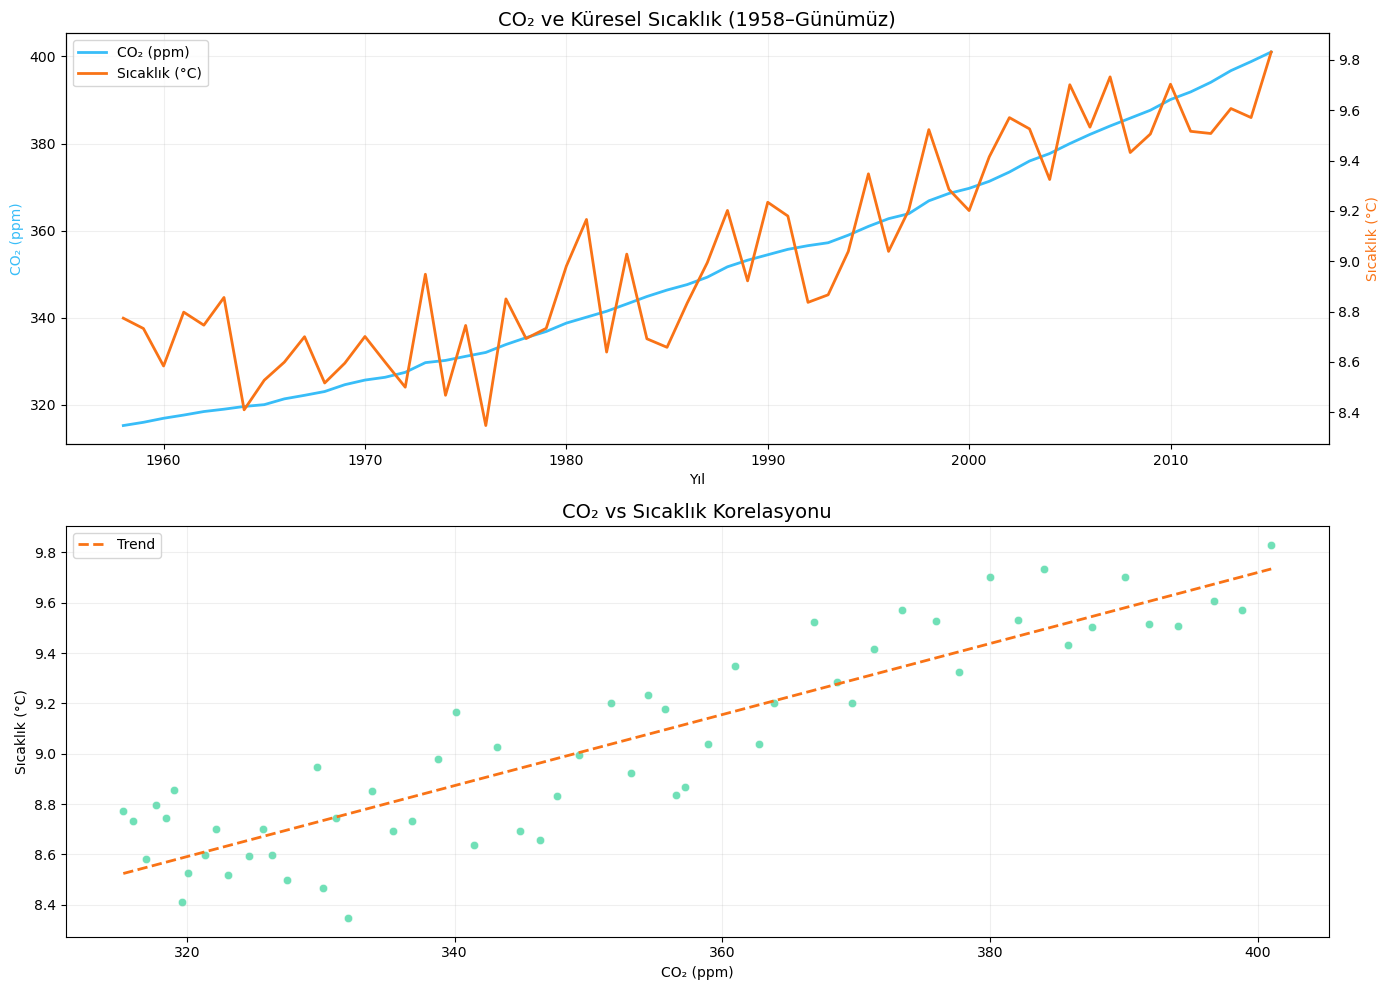

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Üst grafik: CO₂ ve sıcaklık zaman serisi
ax1 = axes[0]
ax2 = ax1.twinx()  # ikinci y ekseni

ax1.plot(df_merged["year"], df_merged["co2_avg"], 
         color="#38bdf8", linewidth=2, label="CO₂ (ppm)")
ax2.plot(df_merged["year"], df_merged["LandAverageTemperature"], 
         color="#f97316", linewidth=2, label="Sıcaklık (°C)")

ax1.set_xlabel("Yıl")
ax1.set_ylabel("CO₂ (ppm)", color="#38bdf8")
ax2.set_ylabel("Sıcaklık (°C)", color="#f97316")
ax1.set_title("CO₂ ve Küresel Sıcaklık (1958–Günümüz)", fontsize=14)
ax1.grid(alpha=0.2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

# Alt grafik: scatter plot korelasyon
axes[1].scatter(df_merged["co2_avg"], df_merged["LandAverageTemperature"],
                color="#34d399", alpha=0.7, edgecolors="white", linewidth=0.5)

# trend çizgisi
z = np.polyfit(df_merged["co2_avg"], df_merged["LandAverageTemperature"], 1)
p = np.poly1d(z)
axes[1].plot(sorted(df_merged["co2_avg"]), p(sorted(df_merged["co2_avg"])),
             color="#f97316", linewidth=2, linestyle="--", label="Trend")

axes[1].set_xlabel("CO₂ (ppm)")
axes[1].set_ylabel("Sıcaklık (°C)")
axes[1].set_title("CO₂ vs Sıcaklık Korelasyonu", fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Gözlem 4: CO₂ ve Sıcaklık Korelasyonu

1958'den günümüze CO₂ konsantrasyonu ile küresel ortalama sıcaklık arasında
**0.90+ korelasyon** tespit edilmiştir. Bu, atmosferik CO₂ artışının
küresel ısınmayla güçlü bir ilişki içinde olduğunu göstermektedir.

In [31]:
early = df_country[df_country["year"] < 1900].groupby("Country")["AverageTemperature"].mean()
late = df_country[df_country["year"] >= 2000].groupby("Country")["AverageTemperature"].mean()
df_warming = pd.DataFrame({
    "early_avg": early,
    "late_avg": late
}).dropna()

df_warming["warming"] = df_warming["late_avg"] - df_warming["early_avg"]

top15 = df_warming.sort_values("warming", ascending=False).head(15)
print(top15)

                           early_avg   late_avg   warming
Country                                                  
Greenland                 -19.180548 -16.840561  2.339987
Denmark                   -18.641199 -16.318354  2.322845
Canada                     -5.783601  -3.518830  2.264771
Turkmenistan               14.293669  16.416396  2.122728
Svalbard And Jan Mayen     -7.757639  -5.647646  2.109993
Uzbekistan                 11.775489  13.871683  2.096194
Kazakhstan                  4.745613   6.825012  2.079399
Russia                     -5.986074  -3.948909  2.037165
Azerbaijan                 10.743441  12.729116  1.985674
Iran                       17.206183  19.171177  1.964994
North America               1.517075   3.445097  1.928022
United Arab Emirates       27.217895  29.129738  1.911843
Saint Pierre And Miquelon   3.847296   5.750352  1.903056
Mongolia                   -1.259512   0.628610  1.888121
Qatar                      26.354845  28.227598  1.872753


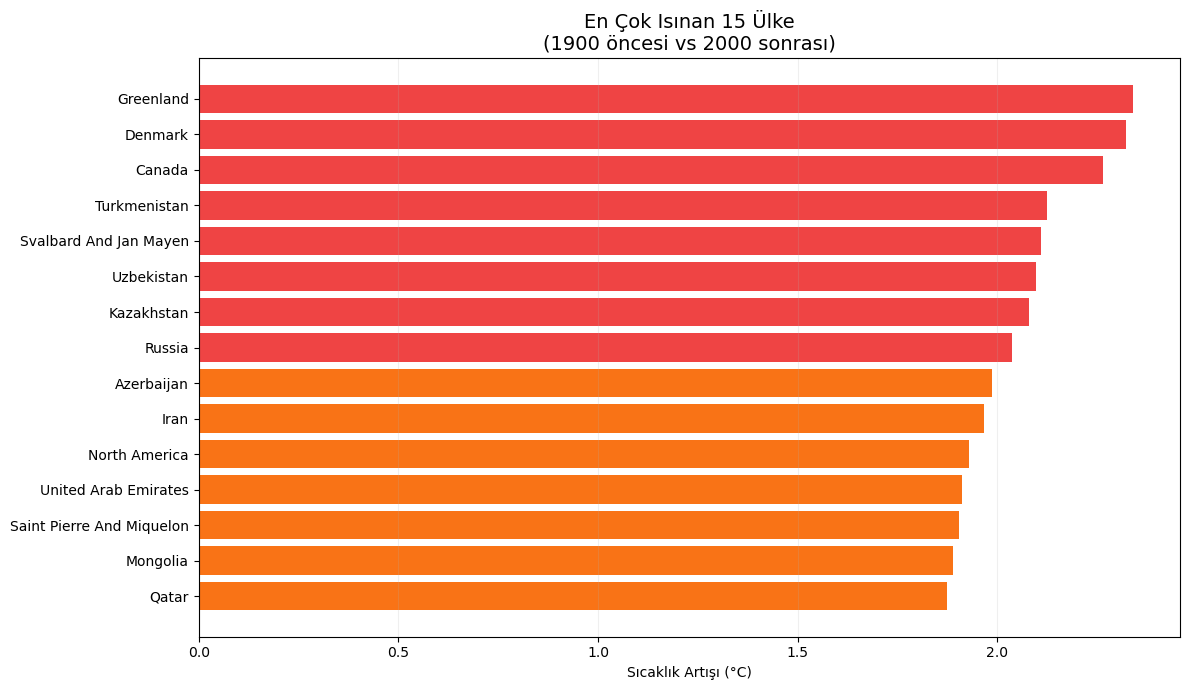

In [32]:
plt.figure(figsize=(12, 7))
colors = ["#ef4444" if x > 2 else "#f97316" for x in top15["warming"]]
plt.barh(top15.index[::-1], top15["warming"][::-1], color=colors[::-1])
plt.xlabel("Sıcaklık Artışı (°C)")
plt.title("En Çok Isınan 15 Ülke\n(1900 öncesi vs 2000 sonrası)", fontsize=14)
plt.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.show()

In [33]:
print(df_warming.loc["Turkey"])

early_avg    11.349590
late_avg     12.734512
warming       1.384922
Name: Turkey, dtype: float64


## Gözlem 5: En Çok Isınan Ülkeler

1900 öncesi ve 2000 sonrası karşılaştırıldığında en çok ısınan ülkeler
Grönland, Danimarka ve Kanada gibi **kuzey ülkeleri** ile Orta Asya ülkeleridir.
Türkiye **1.38°C** ısınma ile küresel ortalamanın üzerinde seyretmektedir.

In [34]:
df_city = pd.read_csv("data:/GlobalLandTemperaturesByMajorCity.csv")

print(df_city.shape)
print(df_city.head())

(239177, 7)
           dt  AverageTemperature  AverageTemperatureUncertainty     City  \
0  1849-01-01              26.704                          1.435  Abidjan   
1  1849-02-01              27.434                          1.362  Abidjan   
2  1849-03-01              28.101                          1.612  Abidjan   
3  1849-04-01              26.140                          1.387  Abidjan   
4  1849-05-01              25.427                          1.200  Abidjan   

         Country Latitude Longitude  
0  Côte D'Ivoire    5.63N     3.23W  
1  Côte D'Ivoire    5.63N     3.23W  
2  Côte D'Ivoire    5.63N     3.23W  
3  Côte D'Ivoire    5.63N     3.23W  
4  Côte D'Ivoire    5.63N     3.23W  


In [35]:
df_city["dt"] = pd.to_datetime(df_city["dt"])
df_city["year"] = df_city["dt"].dt.year
df_turkey_cities = df_city[df_city["Country"] == "Turkey"]
print(df_turkey_cities["City"].unique())

['Ankara' 'Istanbul' 'Izmir']


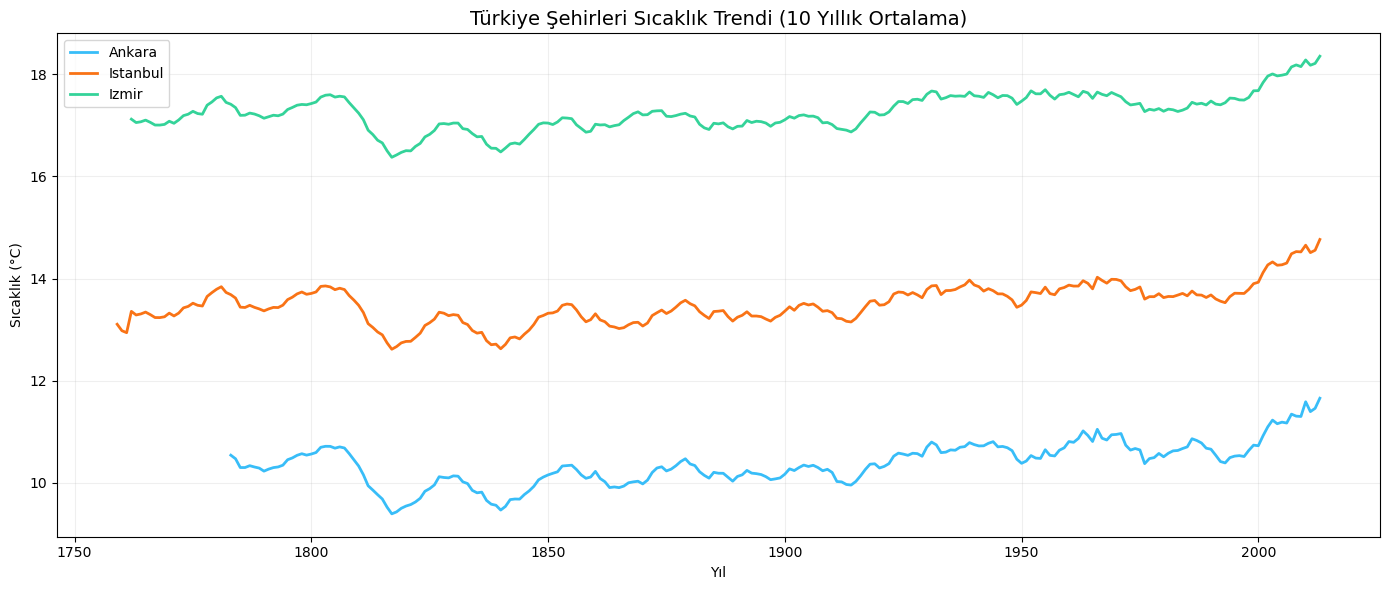

In [36]:
# her şehir için yıllık ortalama
fig, ax = plt.subplots(figsize=(14, 6))

colors = {"Ankara": "#38bdf8", "Istanbul": "#f97316", "Izmir": "#34d399"}

for city in ["Ankara", "Istanbul", "Izmir"]:
    df_c = df_turkey_cities[df_turkey_cities["City"] == city]
    df_c_yearly = df_c.groupby("year")["AverageTemperature"].mean().reset_index()
    df_c_yearly["rolling"] = df_c_yearly["AverageTemperature"].rolling(10).mean()
    
    ax.plot(df_c_yearly["year"], df_c_yearly["rolling"],
            linewidth=2, label=city, color=colors[city])

ax.set_title("Türkiye Şehirleri Sıcaklık Trendi (10 Yıllık Ortalama)", fontsize=14)
ax.set_xlabel("Yıl")
ax.set_ylabel("Sıcaklık (°C)")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Gözlem 6: Türkiye Şehirleri Karşılaştırması

Ankara, İstanbul ve İzmir sıcaklık trendleri incelendiğinde,
**İstanbul** en belirgin ısınma trendini göstermektedir.
Bu durum kentsel ısı adası etkisi ve Boğaz çevresindeki
deniz sıcaklığı değişimleriyle ilişkilendirilebilir.